# Self-Improving AI: Five-Strategy Reinforcement-Learning Toy Model

This executable notebook is organized from `self_improving_ai_5_strategies.py`.
It illustrates a recursive feedback loop in which a more capable AI has a
better chance of successful research, and successful research increases the
capability of the next AI researcher.

The model is intentionally educational rather than a realistic forecast of
frontier AI development.

## Model

For strategy $i$, research succeeds with probability

$$
p_i(A_t)=\sigma\left(\operatorname{logit}(b_i)+s_i(A_t-A_0)\right).
$$

On success, capability changes by

$$
\Delta A_t=g_iA_t(1-A_t), \qquad A_{t+1}=A_t+\Delta A_t.
$$

An epsilon-greedy bandit selects a strategy and updates its estimated value:

$$
Q_i \leftarrow Q_i+\alpha(r_t-Q_i).
$$

## 1. Imports, configuration, and research strategies

In [1]:
%matplotlib inline
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Random seed makes the stochastic simulation reproducible.
RANDOM_SEED = 42

# Number of recursive research / self-improvement cycles.
N_GENERATIONS = 200

# Initial AI capability.
#
# A = 0 means essentially no capability.
# A = 1 represents the theoretical upper bound in this toy model.
INITIAL_CAPABILITY = 0.40


# ---------------------------------------------------------------------
# Reinforcement-learning parameters
# ---------------------------------------------------------------------

# Q-learning update rate.
#
# Higher alpha:
#     agent reacts faster to recent results
#
# Lower alpha:
#     agent changes its beliefs more slowly
#
# We intentionally use a constant alpha because the reward distribution
# changes as AI capability changes.
ALPHA = 0.15


# Initial probability of random exploration.
EPSILON_START = 0.35

# Minimum exploration probability.
#
# Even after learning, we continue experimenting occasionally.
EPSILON_MIN = 0.05

# Controls how quickly epsilon decreases.
EPSILON_DECAY = 0.985


# Initial Q-value assigned to every strategy.
#
# The units are expected capability improvement per experiment.
INITIAL_Q_VALUE = 0.010

"""
Each strategy contains three hidden properties.

The RL agent DOES NOT directly observe these parameters.

base_success:
    Probability that the strategy succeeds when A = INITIAL_CAPABILITY.

gain:
    How much capability improvement the strategy can produce when
    successful.

sensitivity:
    Determines how much the strategy benefits from having a more
    capable AI researcher.

This creates an interesting trade-off.

Some strategies are:

    - easy but produce modest gains
    - difficult but potentially produce large gains

Therefore a strategy that is unattractive for a weak AI may become
very useful once the AI becomes more capable.
"""

STRATEGIES = [
    {
        "name": "Prompt / scaffold",
        "base_success": 0.80,
        "gain": 0.050,
        "sensitivity": 0.40,
    },
    {
        "name": "Search / planning",
        "base_success": 0.65,
        "gain": 0.065,
        "sensitivity": 0.80,
    },
    {
        "name": "Synthetic data",
        "base_success": 0.38,
        "gain": 0.100,
        "sensitivity": 2.00,
    },
    {
        "name": "Fine-tuning",
        "base_success": 0.20,
        "gain": 0.150,
        "sensitivity": 4.00,
    },
    {
        "name": "Inference optimization",
        "base_success": 0.70,
        "gain": 0.055,
        "sensitivity": 0.60,
    },
]

Matplotlib is building the font cache; this may take a moment.


## 2. Mathematical helper functions

These functions define research success, improvement on success, and the hidden expected reward used for evaluation.

In [2]:
def sigmoid(x):
    """
    Standard logistic sigmoid.

    Converts any real number into a value between 0 and 1.

        sigmoid(x) = 1 / (1 + exp(-x))

    We use it to transform research capability into a success
    probability.
    """

    return 1.0 / (1.0 + np.exp(-x))


def logit(p):
    """
    Inverse of the sigmoid function.

        logit(p) = log(p / (1-p))

    Allows us to start with an explicit probability such as 0.80,
    modify it in log-odds space, and convert it back with sigmoid().
    """

    return np.log(p / (1.0 - p))


def research_success_probability(strategy, capability):
    """
    Compute probability that a particular R&D strategy succeeds.

    Mathematical equation:

        p_i(A)
        =
        sigmoid(
            logit(base_success_i)
            +
            sensitivity_i * (A - A_initial)
        )

    Interpretation
    --------------

    If capability = INITIAL_CAPABILITY:

        p_i(A) = base_success_i

    As capability A increases:

        p_i(A) increases.

    Therefore a better AI researcher becomes more effective at
    conducting AI research.

    This is one of the mechanisms that creates recursive improvement.
    """

    base_probability = strategy["base_success"]

    sensitivity = strategy["sensitivity"]

    capability_difference = capability - INITIAL_CAPABILITY

    log_odds = (
        logit(base_probability)
        + sensitivity * capability_difference
    )

    probability = sigmoid(log_odds)

    return probability


def capability_gain(strategy, capability):
    """
    Calculate improvement IF the experiment succeeds.

    Mathematical equation:

        ΔA = gain_i * A * (1 - A)

    Components
    ----------

    gain_i:
        inherent improvement potential of the research strategy

    A:
        more capable AI researchers can exploit discoveries better

    (1 - A):
        diminishing returns

    The product

        A * (1 - A)

    creates an interesting shape.

    When A is low:
        the researcher itself is weak

    When A is moderate:
        improvement can happen quickly

    When A approaches 1:
        diminishing returns dominate
    """

    gain = strategy["gain"]

    delta_A = gain * capability * (1.0 - capability)

    return delta_A


def expected_reward(strategy, capability):
    """
    Calculate the TRUE expected immediate reward of a strategy.

    The agent does NOT know this function.

    It exists so that WE can inspect the simulated environment.

    Expected reward:

        E[r | strategy i, A]

        = P(success | i, A)
          *
          improvement_if_success

    Therefore:

        E[r]
        =
        p_i(A)
        *
        gain_i
        *
        A
        *
        (1 - A)
    """

    probability = research_success_probability(
        strategy,
        capability,
    )

    gain = capability_gain(
        strategy,
        capability,
    )

    return probability * gain

## 3. Epsilon-greedy research policy

The agent explores randomly with probability epsilon and otherwise selects a strategy with the highest learned Q-value.

In [3]:
def choose_strategy(q_values, epsilon, rng):
    """
    Choose an R&D strategy using epsilon-greedy exploration.

    With probability epsilon:

        EXPLORE
        choose a random research strategy

    Otherwise:

        EXPLOIT
        choose the strategy with the highest estimated Q-value


    Returns
    -------

    action : int
        Index of selected strategy.

    mode : str
        Either "explore" or "exploit".
    """

    random_number = rng.random()

    # ---------------------------------------------------------------
    # Exploration
    # ---------------------------------------------------------------

    if random_number < epsilon:

        action = rng.integers(
            low=0,
            high=len(q_values),
        )

        mode = "explore"

        return action, mode

    # ---------------------------------------------------------------
    # Exploitation
    # ---------------------------------------------------------------

    # There can occasionally be ties between Q-values.
    #
    # Instead of always selecting the first strategy, randomly
    # choose among all strategies that have the maximum Q-value.

    max_q = np.max(q_values)

    candidate_actions = np.flatnonzero(
        np.isclose(q_values, max_q)
    )

    action = rng.choice(candidate_actions)

    mode = "exploit"

    return action, mode

## 4. One stochastic R&D experiment

A selected strategy either succeeds and increases capability or fails and produces zero reward.

In [4]:
def run_research_experiment(
    strategy,
    capability,
    rng,
):
    """
    Simulate one research experiment.

    Steps
    -----

    1. Calculate probability that research succeeds.

    2. Randomly determine whether experiment succeeds.

    3. If successful:
           improve AI capability.

       Otherwise:
           no capability improvement.

    4. Return reward = capability improvement.


    This creates stochastic feedback.

    The same research strategy can succeed in one generation and fail
    in another.
    """

    # ---------------------------------------------------------------
    # Probability that research succeeds
    # ---------------------------------------------------------------

    probability_success = research_success_probability(
        strategy,
        capability,
    )

    # ---------------------------------------------------------------
    # Draw random Bernoulli outcome
    # ---------------------------------------------------------------

    random_number = rng.random()

    success = random_number < probability_success

    # ---------------------------------------------------------------
    # Calculate actual improvement
    # ---------------------------------------------------------------

    if success:

        improvement = capability_gain(
            strategy,
            capability,
        )

    else:

        improvement = 0.0

    # Reward is simply improvement in capability.
    reward = improvement

    return success, probability_success, improvement, reward

## 5. Recursive self-improvement simulation

The full loop chooses research, observes the result, updates capability and the selected Q-value, and then repeats.

In [5]:
def run_simulation():
    """
    Run the complete recursive self-improvement process.

    At each generation:

        1. Current AI has capability A_t

        2. RL policy chooses one R&D strategy

        3. AI executes research

        4. Experiment succeeds or fails

        5. Successful experiment changes A_t -> A_(t+1)

        6. RL algorithm observes reward

        7. Q-value of chosen strategy is updated

        8. Improved AI performs the next research cycle

    Returns
    -------

    results_df : pandas.DataFrame
        One row per research generation.

    q_history_df : pandas.DataFrame
        Evolution of learned Q-values.
    """

    # ---------------------------------------------------------------
    # Initialize random generator
    # ---------------------------------------------------------------

    rng = np.random.default_rng(RANDOM_SEED)

    number_of_strategies = len(STRATEGIES)

    # ---------------------------------------------------------------
    # Initial AI capability
    # ---------------------------------------------------------------

    capability = INITIAL_CAPABILITY

    # ---------------------------------------------------------------
    # Initialize Q-values
    # ---------------------------------------------------------------

    q_values = np.full(
        number_of_strategies,
        INITIAL_Q_VALUE,
        dtype=float,
    )

    # ---------------------------------------------------------------
    # Initial epsilon
    # ---------------------------------------------------------------

    epsilon = EPSILON_START

    # ---------------------------------------------------------------
    # Storage for simulation history
    # ---------------------------------------------------------------

    results = []

    q_history = []

    # Store generation-zero Q-values.
    initial_q_row = {
        "generation": 0,
    }

    for i, strategy in enumerate(STRATEGIES):

        initial_q_row[strategy["name"]] = q_values[i]

    q_history.append(initial_q_row)

    # ===============================================================
    # Recursive R&D loop
    # ===============================================================

    for generation in range(
        1,
        N_GENERATIONS + 1,
    ):

        # -----------------------------------------------------------
        # STEP 1:
        # AI enters this generation with capability A_t
        # -----------------------------------------------------------

        capability_before = capability

        # -----------------------------------------------------------
        # STEP 2:
        # RL algorithm chooses research strategy
        # -----------------------------------------------------------

        action, decision_mode = choose_strategy(
            q_values=q_values,
            epsilon=epsilon,
            rng=rng,
        )

        strategy = STRATEGIES[action]

        # -----------------------------------------------------------
        # STEP 3:
        # Run actual R&D experiment
        # -----------------------------------------------------------

        (
            success,
            probability_success,
            improvement,
            reward,
        ) = run_research_experiment(
            strategy=strategy,
            capability=capability_before,
            rng=rng,
        )

        # -----------------------------------------------------------
        # STEP 4:
        # Update AI capability
        # -----------------------------------------------------------

        capability = capability_before + improvement

        # Because capability represents a normalized quantity,
        # ensure numerical errors never push it above 1.
        capability = min(
            capability,
            0.999999,
        )

        # -----------------------------------------------------------
        # STEP 5:
        # Reinforcement-learning Q update
        # -----------------------------------------------------------

        old_q = q_values[action]

        # Temporal-difference error:
        #
        #     reward - current estimate
        #
        prediction_error = reward - old_q

        # Bandit Q update:
        #
        #     Q <- Q + alpha * (reward - Q)
        #
        q_values[action] = (
            old_q
            + ALPHA * prediction_error
        )

        new_q = q_values[action]

        # -----------------------------------------------------------
        # STEP 6:
        # Compute TRUE expected reward for analysis
        # -----------------------------------------------------------

        # The AI does not receive these values.
        #
        # They allow us to compare:
        #
        #     what is actually best
        #
        # versus
        #
        #     what the agent currently believes is best.

        true_expected_rewards = np.array(
            [
                expected_reward(
                    s,
                    capability_before,
                )
                for s in STRATEGIES
            ]
        )

        true_best_action = np.argmax(
            true_expected_rewards
        )

        true_best_strategy = (
            STRATEGIES[
                true_best_action
            ]["name"]
        )

        # -----------------------------------------------------------
        # STEP 7:
        # Save everything from this generation
        # -----------------------------------------------------------

        result_row = {
            "generation": generation,

            "capability_before": capability_before,
            "capability_after": capability,

            "strategy": strategy["name"],
            "action_index": action,

            "decision_mode": decision_mode,

            "epsilon": epsilon,

            "probability_success": probability_success,

            "success": int(success),

            "reward_delta_A": reward,

            "Q_before": old_q,
            "Q_after": new_q,

            "prediction_error": prediction_error,

            "true_expected_reward_selected":
                true_expected_rewards[action],

            "true_best_strategy":
                true_best_strategy,

            "selected_true_best":
                int(action == true_best_action),
        }

        results.append(result_row)

        # -----------------------------------------------------------
        # Save current Q-values
        # -----------------------------------------------------------

        q_row = {
            "generation": generation,
        }

        for i, s in enumerate(STRATEGIES):

            q_row[s["name"]] = q_values[i]

        q_history.append(q_row)

        # -----------------------------------------------------------
        # STEP 8:
        # Reduce exploration gradually
        # -----------------------------------------------------------

        epsilon = max(
            EPSILON_MIN,
            epsilon * EPSILON_DECAY,
        )

    # ---------------------------------------------------------------
    # Convert results into pandas DataFrames
    # ---------------------------------------------------------------

    results_df = pd.DataFrame(
        results
    )

    q_history_df = pd.DataFrame(
        q_history
    )

    return results_df, q_history_df

In [6]:
results_df, q_history_df = run_simulation()

print(f"Completed {len(results_df)} research generations.")
print(f"Final capability: {results_df['capability_after'].iloc[-1]:.6f}")
print(f"Q-value history rows: {len(q_history_df)}")

Completed 200 research generations.
Final capability: 0.999997
Q-value history rows: 201


## 6. Simulation summary and first 15 generations

In [7]:
def print_summary(results_df):
    """
    Print important statistics from the simulation.
    """

    print("\n")
    print("=" * 72)
    print("SELF-IMPROVING AI SIMULATION")
    print("=" * 72)

    initial_capability = INITIAL_CAPABILITY

    final_capability = results_df[
        "capability_after"
    ].iloc[-1]

    total_improvement = (
        final_capability
        - initial_capability
    )

    number_successes = results_df[
        "success"
    ].sum()

    success_rate = results_df[
        "success"
    ].mean()

    exploration_rate = (
        results_df["decision_mode"]
        == "explore"
    ).mean()

    optimal_strategy_rate = results_df[
        "selected_true_best"
    ].mean()

    print(
        f"\nInitial AI capability : "
        f"{initial_capability:.4f}"
    )

    print(
        f"Final AI capability   : "
        f"{final_capability:.4f}"
    )

    print(
        f"Total improvement     : "
        f"{total_improvement:.4f}"
    )

    print(
        f"\nSuccessful experiments: "
        f"{number_successes}"
    )

    print(
        f"Overall success rate  : "
        f"{success_rate:.2%}"
    )

    print(
        f"Exploration rate      : "
        f"{exploration_rate:.2%}"
    )

    print(
        f"True-best strategy selected: "
        f"{optimal_strategy_rate:.2%}"
    )

    # ----------------------------------------------------------------
    # Strategy-level statistics
    # ----------------------------------------------------------------

    strategy_summary = (
        results_df
        .groupby("strategy")
        .agg(
            experiments=("strategy", "size"),
            successes=("success", "sum"),
            success_rate=("success", "mean"),
            average_reward=("reward_delta_A", "mean"),
            total_reward=("reward_delta_A", "sum"),
        )
        .sort_values(
            "total_reward",
            ascending=False,
        )
    )

    print("\n")
    print("=" * 72)
    print("RESULTS BY RESEARCH STRATEGY")
    print("=" * 72)

    print(
        strategy_summary.round(5)
    )

    print("\n")

print_summary(results_df)

columns_to_display = [
    "generation",
    "capability_before",
    "strategy",
    "decision_mode",
    "probability_success",
    "success",
    "reward_delta_A",
    "capability_after",
    "Q_before",
    "Q_after",
]

display(results_df[columns_to_display].head(15).round(5))



SELF-IMPROVING AI SIMULATION

Initial AI capability : 0.4000
Final AI capability   : 1.0000
Total improvement     : 0.6000

Successful experiments: 145
Overall success rate  : 72.50%
Exploration rate      : 9.00%
True-best strategy selected: 28.00%


RESULTS BY RESEARCH STRATEGY
                        experiments  successes  success_rate  average_reward  \
strategy                                                                       
Search / planning                55         39       0.70909         0.00530   
Fine-tuning                      48         33       0.68750         0.00422   
Synthetic data                   34         24       0.70588         0.00147   
Inference optimization           33         24       0.72727         0.00123   
Prompt / scaffold                30         25       0.83333         0.00052   

                        total_reward  
strategy                              
Search / planning            0.29136  
Fine-tuning                  0.20248  
S

,generation,capability_before,strategy,decision_mode,probability_success,success,reward_delta_A,capability_after,Q_before,Q_after
0,1,0.40000,Fine-tuning,exploit,0.20000,0,0.00000,0.40000,0.01000,0.00850
1,2,0.40000,Search / planning,exploit,0.65000,1,0.01560,0.41560,0.01000,0.01084
2,3,0.41560,Search / planning,exploit,0.65283,0,0.00000,0.41560,0.01084,0.00921
3,4,0.41560,Synthetic data,exploit,0.38738,0,0.00000,0.41560,0.01000,0.00850
4,5,0.41560,Prompt / scaffold,exploit,0.80100,0,0.00000,0.41560,0.01000,0.00850
5,6,0.41560,Inference optimization,exploit,0.70196,0,0.00000,0.41560,0.01000,0.00850
6,7,0.41560,Search / planning,exploit,0.65283,1,0.01579,0.43139,0.00921,0.01020
7,8,0.43139,Search / planning,exploit,0.65569,1,0.01594,0.44733,0.01020,0.01106
8,9,0.44733,Search / planning,exploit,0.65856,1,0.01607,0.46340,0.01106,0.01181
9,10,0.46340,Search / planning,exploit,0.66145,1,0.01616,0.47956,0.01181,0.01247


## Plot 1: AI Capability Over Time

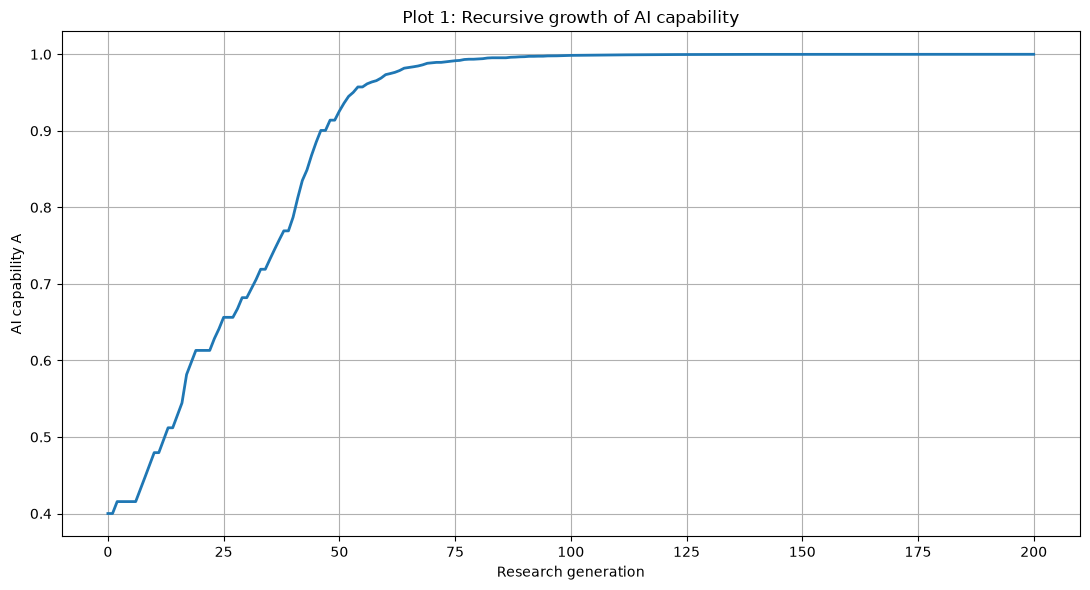

In [8]:
def plot_capability(results_df):
    """
    Show the main recursive self-improvement curve.
    """

    generations = np.concatenate(
        (
            [0],
            results_df["generation"].values,
        )
    )

    capability = np.concatenate(
        (
            [INITIAL_CAPABILITY],
            results_df[
                "capability_after"
            ].values,
        )
    )

    plt.figure(
        figsize=(11, 6)
    )

    plt.plot(
        generations,
        capability,
        linewidth=2,
    )

    plt.xlabel(
        "Research generation"
    )

    plt.ylabel(
        "AI capability A"
    )

    plt.title(
        "Plot 1: Recursive growth of AI capability"
    )

    plt.grid(True)

    plt.tight_layout()

plot_capability(results_df)
plt.show()

**Interpretation.** Capability grows cumulatively: failed experiments create
flat periods and successful experiments create jumps. Recursive improvement
does not need to be continuously exponential. Gains become smaller near the
upper bound because of diminishing returns. The displayed value `1.0000` is a
rounded value; the simulation caps capability at `0.999999`.

## Plot 2: Capability Improvement per Generation

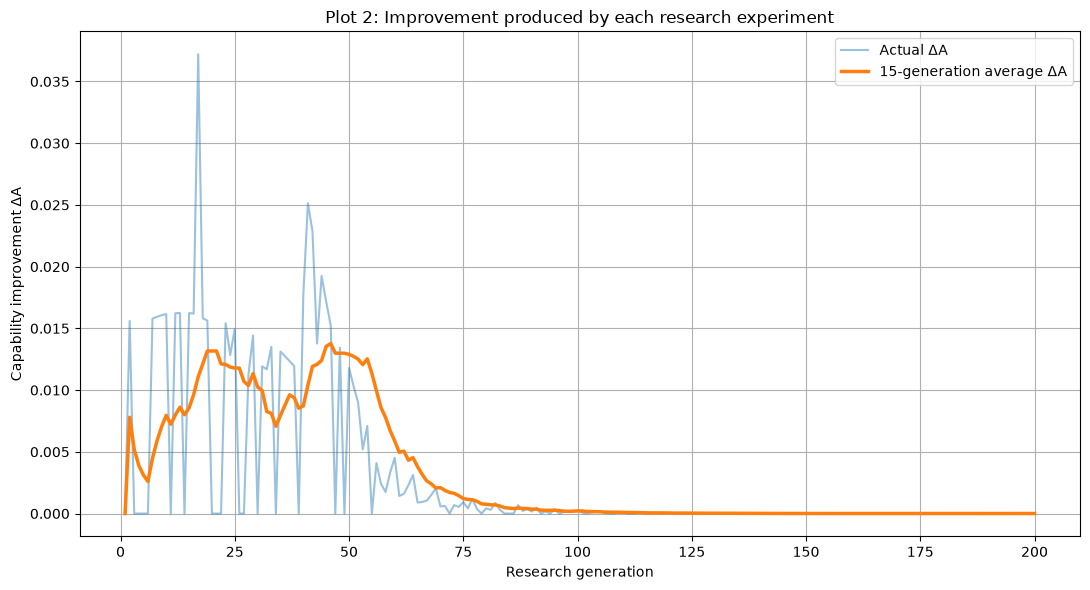

In [9]:
def plot_improvement_per_generation(results_df):
    """
    Show individual research breakthroughs.

    Many experiments fail and produce zero improvement.

    Successful experiments create discrete jumps.
    """

    rolling_reward = (
        results_df[
            "reward_delta_A"
        ]
        .rolling(
            window=15,
            min_periods=1,
        )
        .mean()
    )

    plt.figure(
        figsize=(11, 6)
    )

    plt.plot(
        results_df["generation"],
        results_df["reward_delta_A"],
        alpha=0.45,
        label="Actual ΔA",
    )

    plt.plot(
        results_df["generation"],
        rolling_reward,
        linewidth=2.5,
        label="15-generation average ΔA",
    )

    plt.xlabel(
        "Research generation"
    )

    plt.ylabel(
        "Capability improvement ΔA"
    )

    plt.title(
        "Plot 2: Improvement produced by each research experiment"
    )

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

plot_improvement_per_generation(results_df)
plt.show()

**Interpretation.** The blue line is the actual change in capability
$\Delta A$ from each experiment: zero means no improvement, while a positive
spike represents a successful breakthrough. The orange line is the rolling
average of the blue values over the last 15 generations.

## Plot 3: Learned Q-Values

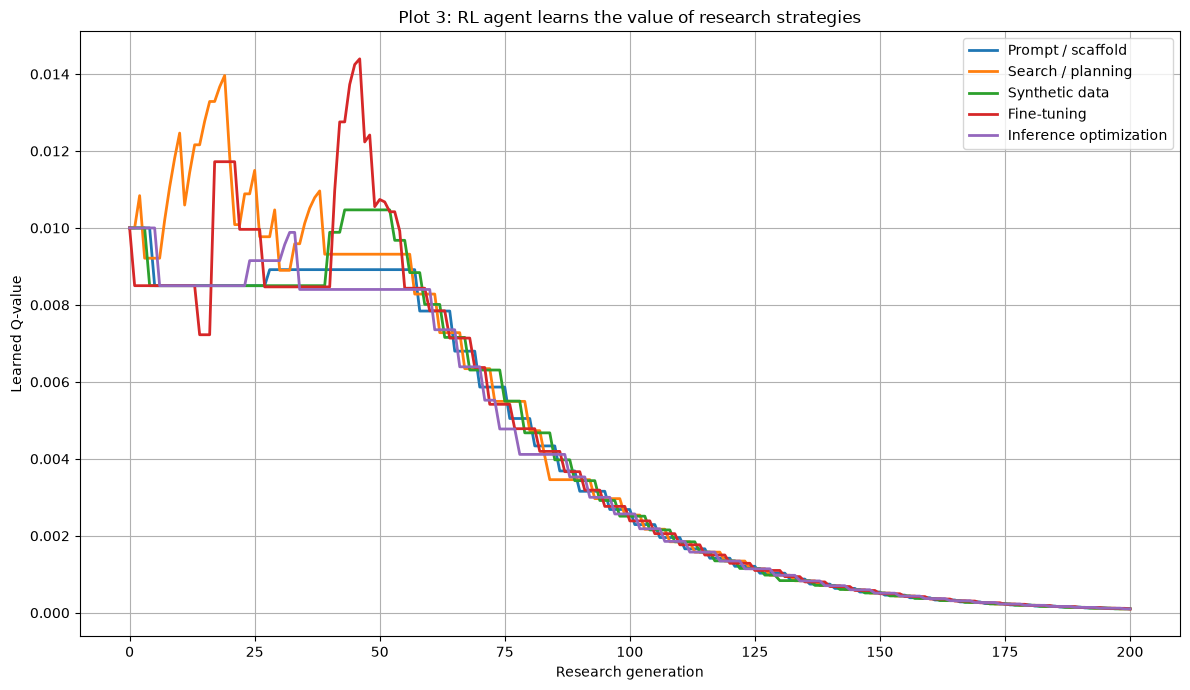

In [10]:
def plot_q_values(q_history_df):
    """
    Show what the RL agent believes each research strategy is worth.

    Q-values are learned entirely from observed experimental rewards.

    Higher Q-value:
        agent expects greater immediate capability improvement.
    """

    plt.figure(
        figsize=(12, 7)
    )

    for strategy in STRATEGIES:

        name = strategy["name"]

        plt.plot(
            q_history_df["generation"],
            q_history_df[name],
            label=name,
            linewidth=2,
        )

    plt.xlabel(
        "Research generation"
    )

    plt.ylabel(
        "Learned Q-value"
    )

    plt.title(
        "Plot 3: RL agent learns the value of research strategies"
    )

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

plot_q_values(q_history_df)
plt.show()

**Interpretation.** Each line is the agent's learned estimate of the immediate
capability gain from one strategy. A Q-value rises after useful successes and
falls after low or zero rewards. The strategy with the highest current Q-value
is normally selected during exploitation; these are learned estimates, not
success probabilities.

## Plot 4: Cumulative Strategy Selection Share

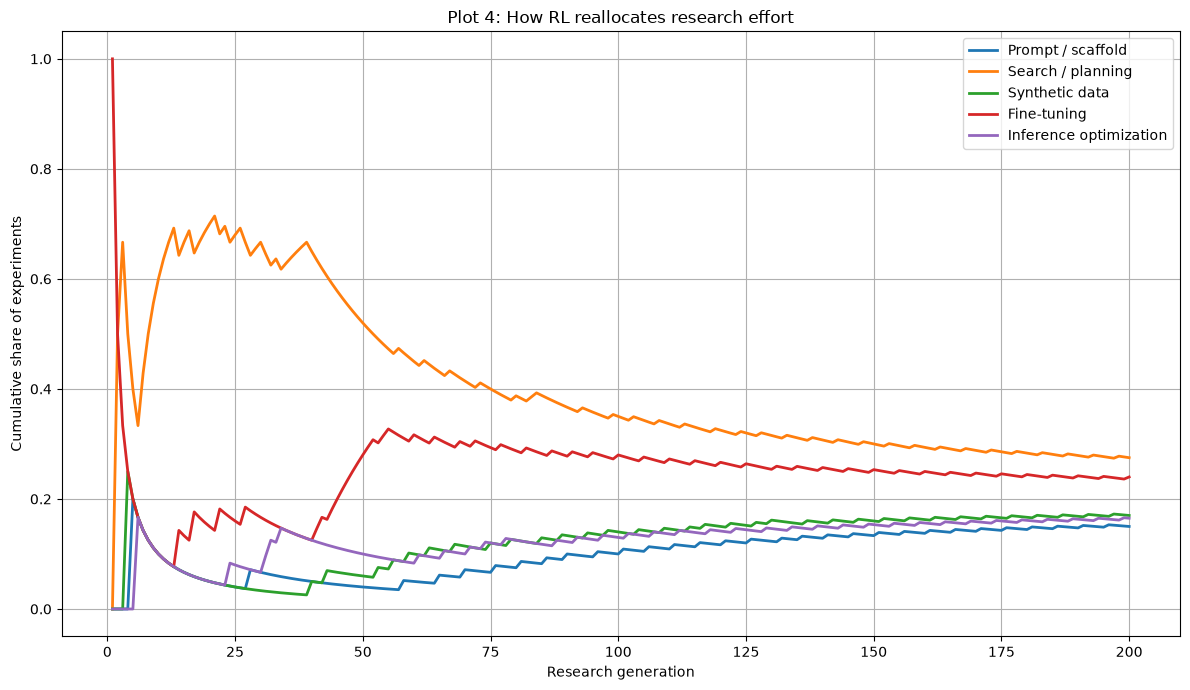

In [11]:
def plot_strategy_selection_share(results_df):
    """
    Show how the agent changes its research allocation.

    Example:

        if Fine-tuning becomes more attractive,
        its cumulative selection share should eventually increase.
    """

    plt.figure(
        figsize=(12, 7)
    )

    generations = results_df[
        "generation"
    ].values

    for strategy in STRATEGIES:

        name = strategy["name"]

        selected = (
            results_df["strategy"]
            == name
        ).astype(int)

        cumulative_count = (
            selected.cumsum()
        )

        cumulative_share = (
            cumulative_count
            / generations
        )

        plt.plot(
            generations,
            cumulative_share,
            label=name,
            linewidth=2,
        )

    plt.xlabel(
        "Research generation"
    )

    plt.ylabel(
        "Cumulative share of experiments"
    )

    plt.title(
        "Plot 4: How RL reallocates research effort"
    )

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

plot_strategy_selection_share(results_df)
plt.show()

**Interpretation.** Each line shows the cumulative proportion of experiments
allocated to one strategy. A rising share means the strategy has been selected
more frequently recently; a falling share means other strategies are receiving
more attention. The changes reflect both learned Q-values and random
exploration.

## Plot 5: Number of Times Each Strategy Was Selected

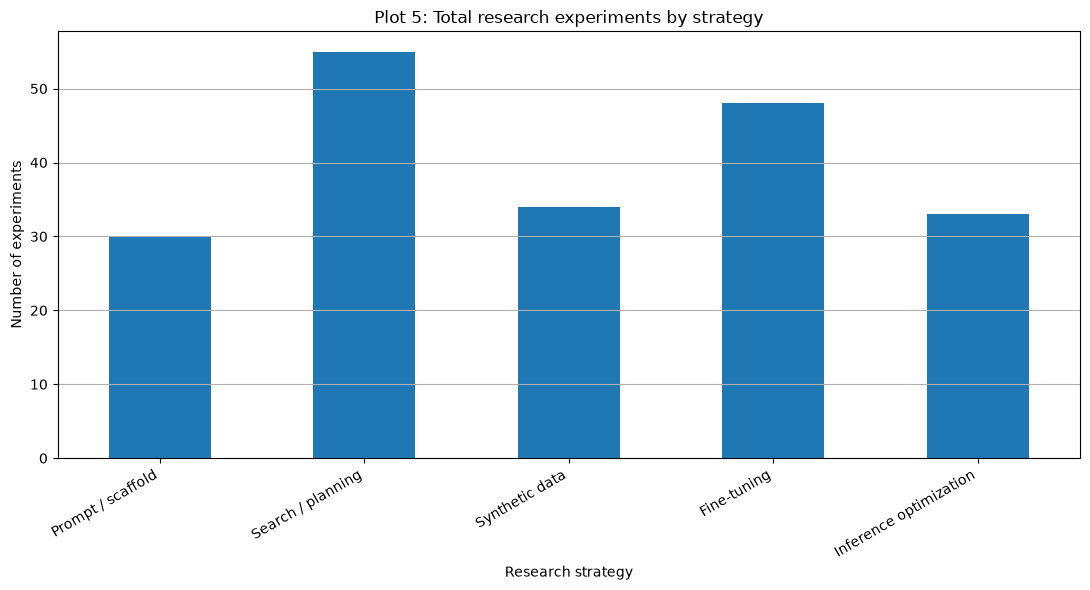

In [12]:
def plot_strategy_counts(results_df):
    """
    Simple bar chart showing total research allocation.
    """

    counts = (
        results_df["strategy"]
        .value_counts()
        .reindex(
            [
                s["name"]
                for s in STRATEGIES
            ]
        )
    )

    plt.figure(
        figsize=(11, 6)
    )

    counts.plot(
        kind="bar"
    )

    plt.xlabel(
        "Research strategy"
    )

    plt.ylabel(
        "Number of experiments"
    )

    plt.title(
        "Plot 5: Total research experiments by strategy"
    )

    plt.xticks(
        rotation=30,
        ha="right",
    )

    plt.grid(
        True,
        axis="y",
    )

    plt.tight_layout()

plot_strategy_counts(results_df)
plt.show()

**Interpretation.** Each bar is the total number of times a strategy was
selected during the 200 generations. Higher counts indicate where the agent
allocated more research effort, reflecting both exploitation of learned
Q-values and occasional random exploration.

## Plot 6: Success Probability of Chosen Research

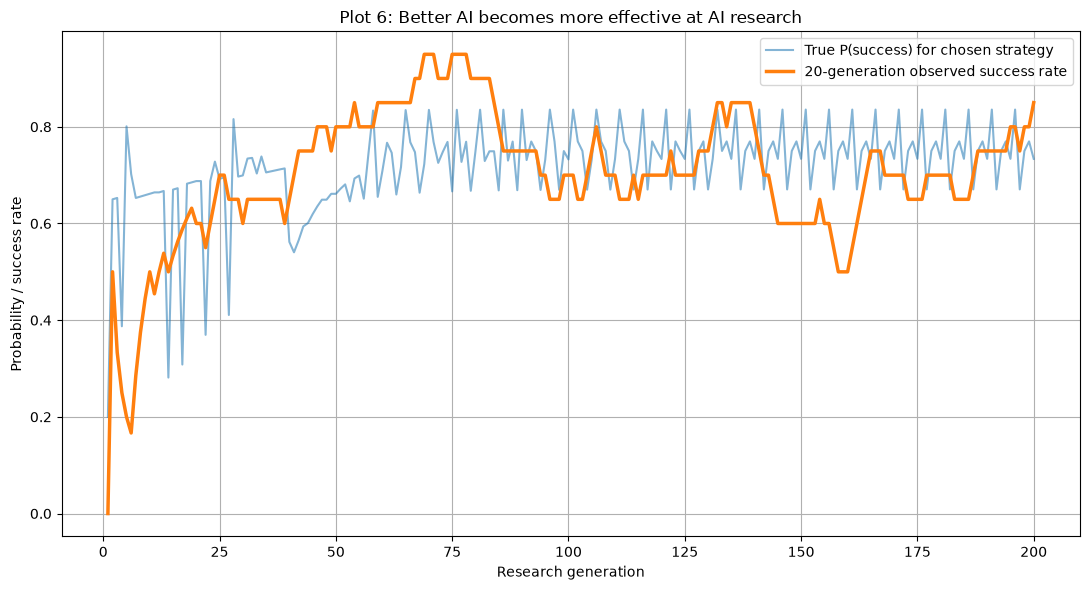

In [13]:
def plot_success_probability(results_df):
    """
    Compare predicted success probability with actual rolling success.

    As AI capability grows, research success probabilities tend to
    improve.
    """

    rolling_success = (
        results_df["success"]
        .rolling(
            window=20,
            min_periods=1,
        )
        .mean()
    )

    plt.figure(
        figsize=(11, 6)
    )

    plt.plot(
        results_df["generation"],
        results_df["probability_success"],
        alpha=0.55,
        label="True P(success) for chosen strategy",
    )

    plt.plot(
        results_df["generation"],
        rolling_success,
        linewidth=2.5,
        label="20-generation observed success rate",
    )

    plt.xlabel(
        "Research generation"
    )

    plt.ylabel(
        "Probability / success rate"
    )

    plt.title(
        "Plot 6: Better AI becomes more effective at AI research"
    )

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

plot_success_probability(results_df)
plt.show()

**Interpretation.** The blue line is the success probability of the strategy
chosen in each generation. It generally increases because greater capability
directly makes every strategy easier to execute, while jumps occur when the
agent switches strategies. The orange line is the rolling average of the
actual binary success outcomes over the last 20 generations. The agent learns
which strategies produce greater rewards, but it is not explicitly given the
best strategy for each capability stage.

## Plot 7: True Expected Reward Landscape

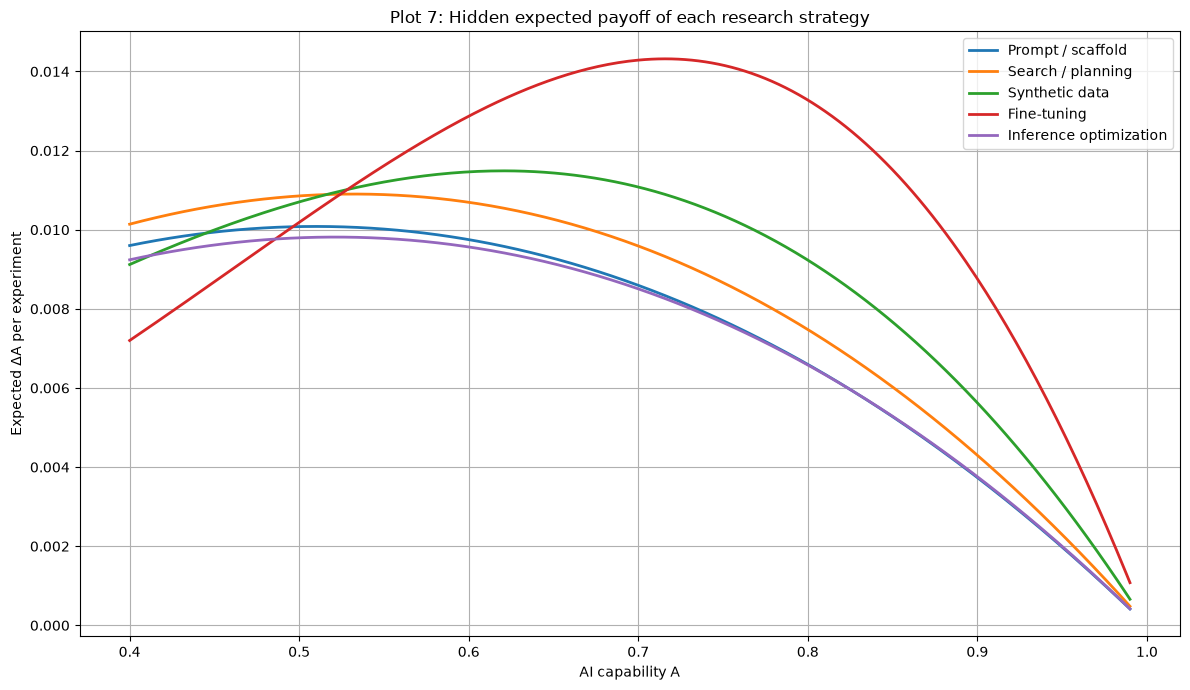

In [14]:
def plot_true_reward_landscape():
    """
    This plot exposes the hidden environment.

    The RL agent does NOT know these curves.

    They show the mathematically expected immediate reward of each
    strategy at different AI capability levels.

    This helps explain why the best R&D strategy can change as the
    AI becomes more capable.
    """

    capability_grid = np.linspace(
        INITIAL_CAPABILITY,
        0.99,
        300,
    )

    plt.figure(
        figsize=(12, 7)
    )

    for strategy in STRATEGIES:

        rewards = [
            expected_reward(
                strategy,
                capability,
            )
            for capability
            in capability_grid
        ]

        plt.plot(
            capability_grid,
            rewards,
            label=strategy["name"],
            linewidth=2,
        )

    plt.xlabel(
        "AI capability A"
    )

    plt.ylabel(
        "Expected ΔA per experiment"
    )

    plt.title(
        "Plot 7: Hidden expected payoff of each research strategy"
    )

    plt.legend()

    plt.grid(True)

    plt.tight_layout()

plot_true_reward_landscape()
plt.show()

**Interpretation.** Each curve is the true expected immediate improvement from
a strategy: success probability multiplied by capability gain on success.
Crossing curves show that the most valuable strategy can change as capability
changes. These curves are hidden from the learning agent.

## Plot 8: Exploration vs. Exploitation

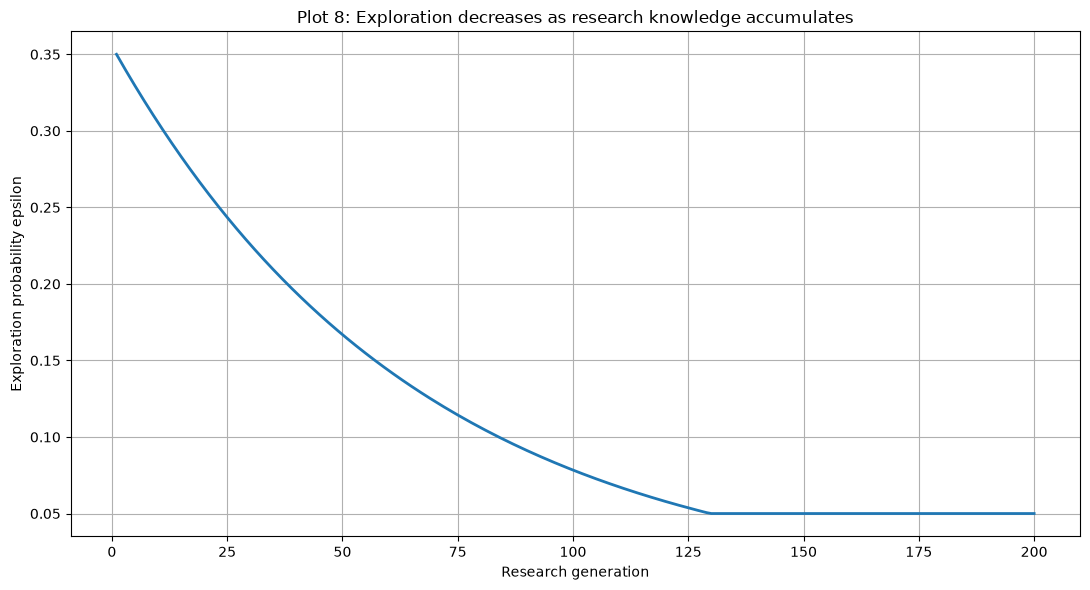

In [15]:
def plot_epsilon(results_df):
    """
    Show how random exploration decreases as the AI learns.

    The minimum exploration rate prevents the system from completely
    stopping experimentation.
    """

    plt.figure(
        figsize=(11, 6)
    )

    plt.plot(
        results_df["generation"],
        results_df["epsilon"],
        linewidth=2,
    )

    plt.xlabel(
        "Research generation"
    )

    plt.ylabel(
        "Exploration probability epsilon"
    )

    plt.title(
        "Plot 8: Exploration decreases as research knowledge accumulates"
    )

    plt.grid(True)

    plt.tight_layout()

plot_epsilon(results_df)
plt.show()

**Interpretation.** Epsilon is the probability of choosing a random strategy.
It declines as experience accumulates, shifting the policy from exploration
toward exploitation, but remains at `0.05` so experimentation never stops
completely.

The policy is mathematically biased toward exploitation from the beginning:
epsilon starts at `0.35`, so the initial exploitation probability is already
`0.65`; after epsilon reaches its minimum, exploitation occurs with probability
`0.95`. This schedule decreases mechanically with generation number rather than
responding to the agent's confidence or whether a situation is easy. Early
decisions labeled `exploit` can also be random among tied Q-values, so the label
does not necessarily mean the agent already knows which strategy is best.

## Plot 9: Frequency of Selecting the True Best Strategy

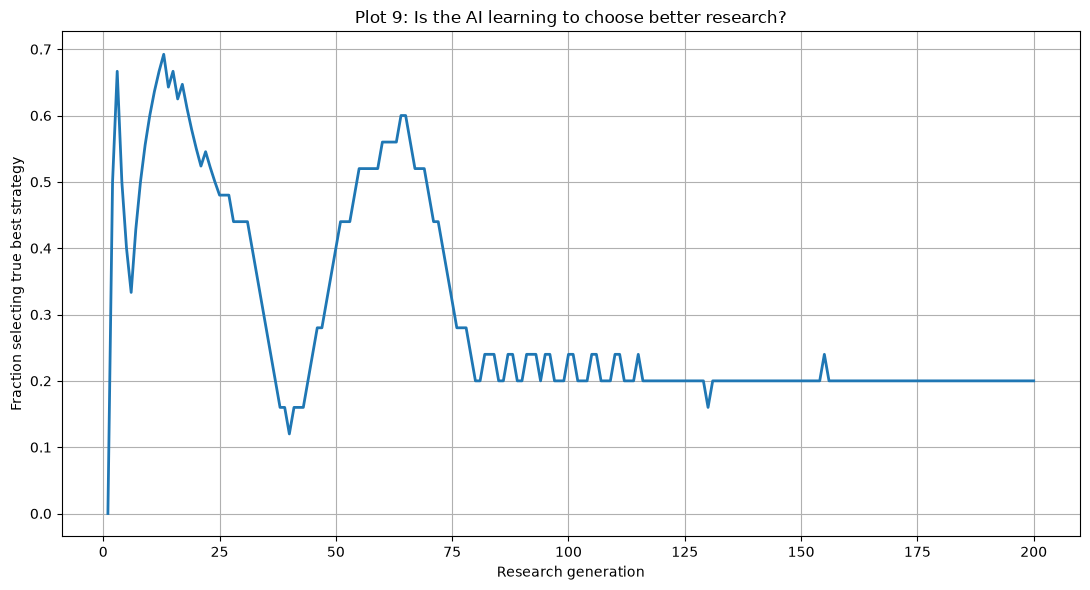

In [16]:
def plot_optimal_strategy_rate(results_df):
    """
    Measure whether the RL researcher becomes better at choosing
    the currently best strategy.

    Because the best strategy may change as capability changes,
    this is a useful measure of research-policy quality.
    """

    rolling_optimal_rate = (
        results_df[
            "selected_true_best"
        ]
        .rolling(
            window=25,
            min_periods=1,
        )
        .mean()
    )

    plt.figure(
        figsize=(11, 6)
    )

    plt.plot(
        results_df["generation"],
        rolling_optimal_rate,
        linewidth=2,
    )

    plt.xlabel(
        "Research generation"
    )

    plt.ylabel(
        "Fraction selecting true best strategy"
    )

    plt.title(
        "Plot 9: Is the AI learning to choose better research?"
    )

    plt.grid(True)

    plt.tight_layout()

plot_optimal_strategy_rate(results_df)
plt.show()

**Interpretation.** The line is the fraction of the last 25 generations in
which the agent selected the strategy with the highest true expected reward.
Higher values indicate better research choices; fluctuations remain because
of exploration, random outcomes, and changes in which strategy is truly best.

# General summary of results

The simulation shows that **recursive AI self-improvement does not imply smooth
or exponential improvement at every generation**. The AI initially does not
know which research strategy will produce the greatest improvement, so
reinforcement learning must balance **exploration** of uncertain alternatives
with **exploitation** of strategies that have performed well. Because
experiments are also stochastic, some generations produce no meaningful
improvement while others produce noticeable jumps.

As capability $A$ increases, however, the AI becomes more effective at
conducting research, which increases the probability that future experiments
succeed. At the same time, the RL agent learns which strategies are more
productive and reallocates research effort toward them. Importantly, the best
strategy can itself change as capability increases, so continued exploration
remains valuable.

Thus, an irregular sequence such as

$$
A_0 \rightarrow A_1 \approx A_0 \rightarrow A_2 \approx A_1
\rightarrow \boxed{A_3 \gg A_2} \rightarrow \cdots
$$

is compatible with recursive self-improvement. A large jump does **not
necessarily represent a single conceptual breakthrough**. In this model it can
result from the combination of **accumulated capability from previous
generations, selecting a higher-value research strategy, and stochastic
experimental success**. Conversely, later progress eventually slows because
the model includes diminishing returns as $A$ approaches its upper bound.

So the central result is:

$$
\boxed{
\text{better AI}
\rightarrow \text{better research}
\rightarrow \text{better strategy selection}
\rightarrow \text{better AI}
}
$$

but the path through that positive-feedback loop can be **uneven, uncertain,
and punctuated by occasional larger improvements rather than continuously
exponential**.

## 7. Save the detailed simulation data

In [17]:
def save_results(
    results_df,
    q_history_df,
):
    """
    Save detailed simulation results so they can be analyzed later
    with pandas, Excel, or another notebook.
    """

    results_df.to_csv(
        "self_improving_ai_results.csv",
        index=False,
    )

    q_history_df.to_csv(
        "self_improving_ai_q_values.csv",
        index=False,
    )

    print(
        "Saved:"
    )

    print(
        "  self_improving_ai_results.csv"
    )

    print(
        "  self_improving_ai_q_values.csv"
    )

save_results(results_df, q_history_df)

Saved:
  self_improving_ai_results.csv
  self_improving_ai_q_values.csv


# Sources, academic citation, and authorship disclosure

## How to describe this notebook academically

This program is an original, stylized teaching simulation rather than a
reproduction of a published model. A concise and defensible description is:

> *A stylized simulation inspired by recursive AI-R&D feedback models, with
> research-strategy selection modeled as an epsilon-greedy multi-armed bandit
> following Sutton and Barto.*

The assumptions, five strategy categories, parameter values, normalized
capability scale, and logistic improvement equations are illustrative modeling
choices. They should not be interpreted as empirically estimated properties of
real AI systems or as forecasts of AI progress.

## Core references

1. **Sutton, R. S., & Barto, A. G. (2018).** *Reinforcement Learning: An
   Introduction* (2nd ed.), Chapter 2: Multi-armed Bandits. MIT Press.
   [Publisher page](https://mitpress.ublish.com/book/reinforcement-learning-an-introduction-2) ·
   [Book PDF](https://msdnaa.eecs.berkeley.edu/~cs188/fa19/assets/files/SuttonBartoIPRLBook2ndEd.pdf)

   This is the methodological source for epsilon-greedy action selection,
   incremental action-value estimation, and constant-step-size updates in a
   nonstationary setting.

2. **Srikanth, D., Zhao, B., Xu, D., Wu, Y., & Jiang, Z. (2026).** “Recursive
   self-improvement of AI research agents.” *arXiv:2609.26457*.
   [arXiv record](https://arxiv.org/abs/2609.26457) ·
   [DOI](https://doi.org/10.48550/arXiv.2609.26457)

   AIDE² provides a contemporary example of an AI research agent recursively
   improving its own research process. It also reports a learned UCB-style
   bandit policy over five drafting strategies. This is closely related to the
   notebook's theme, but it is **not** the same algorithm or the same set of
   five strategies used here.

3. **Chan, A., Winter, C., Barto, A., Pachocki, J., Hinton, G., Horvitz, E.,
   Bengio, Y., Song, D., Clark, J., Greaves, H., Korinek, A., Hammond, S.,
   Graepel, T., Bariach, B., Torr, P. H. S., McIlraith, S. A., Clune, J.,
   Manning, S., Sastry, G., Davidson, T., Eth, D., & Mindermann, S. (2026).**
   “What if automating AI R&D triggers an intelligence explosion?” Cambridge
   Programme on AI Science & Policy (CASP), University of Cambridge.
   [CASP research article](https://casp.ac/reports/intelligence-explosion)

   This source motivates the broader conceptual feedback loop represented by
   the notebook: greater AI capability can make AI R&D more effective, which
   can produce further improvements in AI capability.

## Relationship to AIDE²

A future variant of this simulation could replace epsilon-greedy selection
with a UCB policy and redefine the actions to more closely follow AIDE²'s five
drafting strategies. Such a variant could accurately be described as a
simplified simulation inspired by AIDE². The present notebook should instead
be described using the wording above, because its strategy definitions and
mathematical environment were independently specified for this toy example.

## Human–AI authorship and provenance disclosure

This notebook was created through **human–AI collaboration**. A human provided
the objectives, requested characteristics, conceptual interpretations, and
revision instructions. An AI assistant translated those requests into the
Python simulation, notebook organization, explanatory text, execution, and
plots. The resulting program reflects human-directed design choices combined
with AI-assisted drafting and implementation.

Anyone using this notebook for academic or professional work should review the
code, validate the assumptions, disclose AI assistance as required by their
institution or publisher, and cite the underlying sources rather than treating
this notebook as a peer-reviewed scientific model.